In [1]:
# ==========================
# MISSING VALUES HANDLING 
# ==========================

import pandas as pd
import numpy as np
import os

# ============================================
# STEP 1: Load dataset
# ============================================

# load dataset
input_file = 'phishing_website_full.csv'

if not os.path.exists(input_file):
    print(f"⚠️ Error: '{input_file}' file not found")
else:
    df = pd.read_csv(input_file)

df_clean = df.copy()

print("=" * 70)
print("STEP 1: Identifying columns with encoded missing values (-1)")
print("=" * 70)

missing_cols = []

for col in df_clean.columns:

    # Skip target variable
    if col == 'phishing':
        continue

    if (df_clean[col] == -1).sum() > 0:
        missing_cols.append(col)

print(f"\nFound {len(missing_cols)} columns with -1 values:")
print("-" * 70)

for col in missing_cols:
    missing_count = (df_clean[col] == -1).sum()
    missing_pct = missing_count / len(df_clean) * 100

    print(
        f"  • {col}: "
        f"{missing_count:,} missing "
        f"({missing_pct:.2f}%)"
    )


# ============================================
# STEP 2: Decide handling strategy
# ============================================

print("\n" + "=" * 70)
print("STEP 2: Handling strategy")
print("=" * 70)

DROP_THRESHOLD = 50

cols_to_drop = []
cols_to_impute_median = []
cols_to_impute_mode = []

for col in missing_cols:

    missing_pct = (
        (df_clean[col] == -1).sum()
        / len(df_clean)
        * 100
    )

    if missing_pct > DROP_THRESHOLD:

        cols_to_drop.append(col)

        print(
            f"  → {col}: "
            f"{missing_pct:.1f}% missing "
            f"→ WILL BE DROPPED"
        )

    elif missing_pct > 10:

        cols_to_impute_median.append(col)

        print(
            f"  → {col}: "
            f"{missing_pct:.1f}% missing "
            f"→ MEDIAN IMPUTATION"
        )

    else:

        cols_to_impute_mode.append(col)

        print(
            f"  → {col}: "
            f"{missing_pct:.1f}% missing "
            f"→ MODE IMPUTATION"
        )


# ============================================
# STEP 3: Drop columns
# ============================================

print("\n" + "=" * 70)
print("STEP 3: Applying handling strategies")
print("=" * 70)

if cols_to_drop:

    print(
        f"\nDropping {len(cols_to_drop)} columns "
        f"with >{DROP_THRESHOLD}% missing values:"
    )

    for col in cols_to_drop:
        print(f"  ✗ Dropped: {col}")

    df_clean = df_clean.drop(
        columns=cols_to_drop
    )

else:

    print("\nNo columns need to be dropped.")


# ============================================
# STEP 4: Median Imputation
# ============================================

if cols_to_impute_median:

    print(
        f"\nImputing {len(cols_to_impute_median)} "
        f"columns with MEDIAN:"
    )

    for col in cols_to_impute_median:

        # Calculate median excluding -1
        col_data = df_clean.loc[
            df_clean[col] != -1,
            col
        ]

        median_val = col_data.median()

        # Replace -1 with median
        missing_mask = df_clean[col] == -1

        missing_count = missing_mask.sum()

        df_clean.loc[
            missing_mask,
            col
        ] = median_val

        print(
            f"  ✓ {col}: "
            f"Replaced {missing_count:,} "
            f"values with median = {median_val}"
        )


# ============================================
# STEP 5: Mode Imputation
# ============================================

if cols_to_impute_mode:

    print(
        f"\nImputing {len(cols_to_impute_mode)} "
        f"columns with MODE:"
    )

    for col in cols_to_impute_mode:

        # Calculate mode excluding -1
        col_data = df_clean.loc[
            df_clean[col] != -1,
            col
        ]

        mode_values = col_data.mode()

        if len(mode_values) > 0:
            mode_val = mode_values.iloc[0]
        else:
            mode_val = 0

        # Replace -1 with mode
        missing_mask = df_clean[col] == -1

        missing_count = missing_mask.sum()

        df_clean.loc[
            missing_mask,
            col
        ] = mode_val

        print(
            f"  ✓ {col}: "
            f"Replaced {missing_count:,} "
            f"values with mode = {mode_val}"
        )


# ============================================
# STEP 6: Remove duplicate rows
# ============================================

print("\n" + "=" * 70)
print("STEP 6: Handling duplicate rows")
print("=" * 70)

duplicates_before = df_clean.duplicated().sum()

print(
    f"\n• Duplicate rows before removal: "
    f"{duplicates_before:,}"
)

if duplicates_before > 0:

    df_clean = df_clean.drop_duplicates()

    duplicates_after = df_clean.duplicated().sum()

    print(
        f"• Duplicate rows after removal: "
        f"{duplicates_after:,}"
    )

    print(
        f"• Removed {duplicates_before:,} "
        f"duplicate rows"
    )

else:

    print("• No duplicate rows to remove.")


# ============================================
# STEP 7: Final verification
# ============================================

print("\n" + "=" * 70)
print("STEP 7: Final verification")
print("=" * 70)

# Check remaining -1 values
remaining_minus_one = (
    df_clean == -1
).sum().sum()

print(
    f"\n• Remaining -1 values: "
    f"{remaining_minus_one:,}"
)

# Check remaining NaN values
remaining_nan = df_clean.isna().sum().sum()

print(
    f"• Remaining NaN values: "
    f"{remaining_nan:,}"
)

# Shape comparison
print(
    f"• Original dataset shape: "
    f"{df.shape}"
)

print(
    f"• Cleaned dataset shape: "
    f"{df_clean.shape}"
)

print(
    f"• Rows removed: "
    f"{df.shape[0] - df_clean.shape[0]:,}"
)

print(
    f"• Columns removed: "
    f"{df.shape[1] - df_clean.shape[1]}"
)


# ============================================
# STEP 8: Target verification
# ============================================

print("\n" + "=" * 70)
print("TARGET VARIABLE")
print("=" * 70)

print(
    f"\n• Target data type: "
    f"{df_clean['phishing'].dtype}"
)

print(
    f"\n• Target distribution:"
)

print(
    df_clean['phishing'].value_counts()
)


# ============================================
# STEP 9: Display cleaned dataset
# ============================================

print("\n" + "=" * 70)
print("CLEANED DATASET PREVIEW")
print("=" * 70)
print(df_clean.head())


# ============================================
# STEP 10: SAVE CLEANED DATASET LOCALLY
# ============================================

output_file = 'phishing_website_cleaned.csv'
df_clean.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print(f"✓ Cleaned dataset saved successfully as: {output_file}")
print("=" * 70)

STEP 1: Identifying columns with encoded missing values (-1)

Found 66 columns with -1 values:
----------------------------------------------------------------------
  • qty_dot_directory: 5,289 missing (52.90%)
  • qty_hyphen_directory: 5,289 missing (52.90%)
  • qty_underline_directory: 5,289 missing (52.90%)
  • qty_slash_directory: 5,289 missing (52.90%)
  • qty_questionmark_directory: 5,289 missing (52.90%)
  • qty_equal_directory: 5,289 missing (52.90%)
  • qty_at_directory: 5,289 missing (52.90%)
  • qty_and_directory: 5,289 missing (52.90%)
  • qty_exclamation_directory: 5,289 missing (52.90%)
  • qty_space_directory: 5,289 missing (52.90%)
  • qty_tilde_directory: 5,289 missing (52.90%)
  • qty_comma_directory: 5,289 missing (52.90%)
  • qty_plus_directory: 5,289 missing (52.90%)
  • qty_asterisk_directory: 5,289 missing (52.90%)
  • qty_hashtag_directory: 5,289 missing (52.90%)
  • qty_dollar_directory: 5,289 missing (52.90%)
  • qty_percent_directory: 5,289 missing (52.90%)


In [2]:
# =====================
# DATA TRANSFORMATION
# =====================

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Use the cleaned dataset
df_transformed = df_clean.copy()

print("Original shape:", df_transformed.shape)

# ============================================
# Separate features and target
# ============================================

X = df_transformed.drop(columns=['phishing'])
y = df_transformed['phishing']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# ============================================
# Combine features and target
# ============================================

df_transformed = pd.concat([X_scaled, y], axis=1)

# ============================================
# Check the result
# ============================================

print("\nTransformed dataset shape:", df_transformed.shape)

print("\nFirst 5 rows:")
print(df_transformed.head())

print("\nMean of features after scaling:")
print(X_scaled.mean().round(2))

print("\nStandard deviation of features:")
print(X_scaled.std().round(2))

# ============================================
# Save transformed dataset
# ============================================

df_transformed.to_csv(
    'phishing_website_transformed.csv',
    index=False
)

print("\n✓ Transformed dataset saved successfully!")

Original shape: (9944, 56)
Features shape: (9944, 55)
Target shape: (9944,)

Transformed dataset shape: (9944, 56)

First 5 rows:
   qty_dot_url  qty_hyphen_url  qty_underline_url  qty_slash_url  \
0     0.654217       -0.299247          -0.168522      -0.161613   
1     2.278164       -0.299247           1.203944       0.880594   
2    -0.157757       -0.299247          -0.168522      -0.161613   
3     1.466191       -0.299247           2.576410       1.922801   
4    -0.157757       -0.299247          -0.168522      -0.682717   

   qty_questionmark_url  qty_equal_url  qty_at_url  qty_and_url  \
0             -0.077832      -0.210891   -0.145548    -0.148949   
1             -0.077832       2.883703   -0.145548     1.980663   
2             -0.077832      -0.210891   -0.145548    -0.148949   
3             -0.077832      -0.210891   -0.145548    -0.148949   
4             -0.077832      -0.210891   -0.145548    -0.148949   

   qty_exclamation_url  qty_space_url  ...  qty_ip_resolve

In [3]:
# =====================
# FEATURE SELECTION
# =====================

import pandas as pd
import numpy as np

# ============================================
# STEP 1: Load the transformed dataset
# ============================================

df_feature = pd.read_csv('phishing_website_transformed.csv')

print("=" * 70)
print("FEATURE SELECTION")
print("=" * 70)

print("\nOriginal transformed dataset shape:")
print(df_feature.shape)


# ============================================
# STEP 2: Separate features and target
# ============================================

X = df_feature.drop(columns=['phishing'])
y = df_feature['phishing']

print("\nNumber of features before selection:", X.shape[1])


# ============================================
# STEP 3: Remove constant features
# ============================================

print("\n" + "=" * 70)
print("STEP 1: Removing Constant Features")
print("=" * 70)

# Find features with only one unique value
constant_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print(f"\nConstant features found: {len(constant_features)}")

if constant_features:
    print("\nFeatures to remove:")
    for col in constant_features:
        print("  ✗", col)

    X = X.drop(columns=constant_features)

else:
    print("✓ No constant features found.")


# ============================================
# STEP 4: Correlation with target
# ============================================

print("\n" + "=" * 70)
print("STEP 2: Feature Correlation with Target")
print("=" * 70)

# Calculate correlation between each feature and phishing
correlation = X.corrwith(y)

# Sort by absolute correlation
correlation_sorted = correlation.abs().sort_values(
    ascending=False
)

print("\nTop 15 features based on correlation:")

for feature in correlation_sorted.head(15).index:
    print(
        f"  {feature}: "
        f"{correlation[feature]:.4f}"
    )


# ============================================
# STEP 5: Select important features
# ============================================

print("\n" + "=" * 70)
print("STEP 3: Selecting Important Features")
print("=" * 70)

# Minimum correlation threshold
CORRELATION_THRESHOLD = 0.05

selected_features = correlation[
    correlation.abs() >= CORRELATION_THRESHOLD
].index.tolist()

print(
    f"\nCorrelation threshold: "
    f"{CORRELATION_THRESHOLD}"
)

print(
    f"Features selected: "
    f"{len(selected_features)}"
)

print("\nSelected features:")

for feature in selected_features:
    print("  ✓", feature)


# ============================================
# STEP 6: Create selected feature dataset
# ============================================

X_selected = X[selected_features]

df_selected = pd.concat(
    [
        X_selected,
        y.rename('phishing')
    ],
    axis=1
)

print("\n" + "=" * 70)
print("STEP 4: Final Feature Selection Result")
print("=" * 70)

print(
    f"\nBefore feature selection: "
    f"{df_feature.shape[1] - 1} features"
)

print(
    f"After feature selection: "
    f"{X_selected.shape[1]} features"
)

print(
    f"Rows: "
    f"{df_selected.shape[0]}"
)

print(
    f"Final dataset shape: "
    f"{df_selected.shape}"
)


# ============================================
# STEP 7: Display selected dataset
# ============================================

print("\nFirst 5 rows of selected dataset:")
print(df_selected.head())


# ============================================
# STEP 8: Save selected dataset
# ============================================

output_file = 'phishing_website_feature_selected.csv'

df_selected.to_csv(
    output_file,
    index=False
)

print(
    f"\n✓ Feature-selected dataset saved as: "
    f"{output_file}"
)

FEATURE SELECTION

Original transformed dataset shape:
(9944, 56)

Number of features before selection: 55

STEP 1: Removing Constant Features

Constant features found: 15

Features to remove:
  ✗ qty_hashtag_url
  ✗ qty_slash_domain
  ✗ qty_questionmark_domain
  ✗ qty_equal_domain
  ✗ qty_at_domain
  ✗ qty_and_domain
  ✗ qty_exclamation_domain
  ✗ qty_space_domain
  ✗ qty_tilde_domain
  ✗ qty_comma_domain
  ✗ qty_plus_domain
  ✗ qty_asterisk_domain
  ✗ qty_hashtag_domain
  ✗ qty_dollar_domain
  ✗ qty_percent_domain

STEP 2: Feature Correlation with Target

Top 15 features based on correlation:
  qty_slash_url: 0.6929
  length_url: 0.4819
  time_domain_activation: -0.4771
  qty_dot_domain: -0.2556
  qty_equal_url: 0.2499
  qty_tld_url: 0.2209
  email_in_url: 0.2014
  qty_at_url: 0.1982
  qty_hyphen_url: 0.1974
  qty_and_url: 0.1829
  qty_underline_url: 0.1815
  qty_dot_url: 0.1762
  time_domain_expiration: -0.1602
  qty_hyphen_domain: 0.1264
  domain_spf: 0.1158

STEP 3: Selecting Impo

In [4]:
# =====================
# DATA NORMALIZATION
# =====================

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ============================================
# STEP 1: Load Feature-Selected Dataset
# ============================================

df_normalization = pd.read_csv(
    'phishing_website_feature_selected.csv'
)

print("=" * 70)
print("DATA NORMALIZATION")
print("=" * 70)

print("\nOriginal feature-selected dataset shape:")
print(df_normalization.shape)


# ============================================
# STEP 2: Separate Features and Target
# ============================================

X = df_normalization.drop(columns=['phishing'])
y = df_normalization['phishing']

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


# ============================================
# STEP 3: Check Feature Range Before Normalization
# ============================================

print("\n" + "=" * 70)
print("STEP 1: Before Normalization")
print("=" * 70)

print("\nFeature minimum values:")
print(X.min().head())

print("\nFeature maximum values:")
print(X.max().head())


# ============================================
# STEP 4: Apply Min-Max Normalization
# ============================================

print("\n" + "=" * 70)
print("STEP 2: Applying Min-Max Normalization")
print("=" * 70)

# MinMaxScaler transforms values to range [0, 1]
scaler = MinMaxScaler()

X_normalized = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("✓ Min-Max Normalization completed!")


# ============================================
# STEP 5: Combine Normalized Features with Target
# ============================================

df_normalized = pd.concat(
    [
        X_normalized,
        y
    ],
    axis=1
)

print("\n" + "=" * 70)
print("STEP 3: Final Normalized Dataset")
print("=" * 70)

print("\nNormalized dataset shape:")
print(df_normalized.shape)

print("\nFirst 5 rows:")
print(df_normalized.head())


# ============================================
# STEP 6: Verify Normalization
# ============================================

print("\n" + "=" * 70)
print("STEP 4: Verify Normalization")
print("=" * 70)

print(
    "\nMinimum feature value:",
    X_normalized.min().min()
)

print(
    "Maximum feature value:",
    X_normalized.max().max()
)

print(
    "\nMissing values:",
    df_normalized.isna().sum().sum()
)

print(
    "\nTarget values:"
)

print(
    df_normalized['phishing'].value_counts()
)


# ============================================
# STEP 7: Save Normalized Dataset
# ============================================

output_file = 'phishing_website_normalized.csv'

df_normalized.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("DATA NORMALIZATION COMPLETE")
print("=" * 70)

print(
    f"\n✓ Normalized dataset saved as: "
    f"{output_file}"
)

DATA NORMALIZATION

Original feature-selected dataset shape:
(9944, 25)

Features shape: (9944, 24)
Target shape: (9944,)

STEP 1: Before Normalization

Feature minimum values:
qty_dot_url            -0.969730
qty_hyphen_url         -0.299247
qty_underline_url      -0.168522
qty_slash_url          -0.682717
qty_questionmark_url   -0.077832
dtype: float64

Feature maximum values:
qty_dot_url             14.457769
qty_hyphen_url          17.092416
qty_underline_url       28.653264
qty_slash_url            9.218253
qty_questionmark_url    31.728844
dtype: float64

STEP 2: Applying Min-Max Normalization
✓ Min-Max Normalization completed!

STEP 3: Final Normalized Dataset

Normalized dataset shape:
(9944, 25)

First 5 rows:
   qty_dot_url  qty_hyphen_url  qty_underline_url  qty_slash_url  \
0     0.105263             0.0           0.000000       0.052632   
1     0.210526             0.0           0.047619       0.157895   
2     0.052632             0.0           0.000000       0.052632   

In [ ]:
# Data Visualization

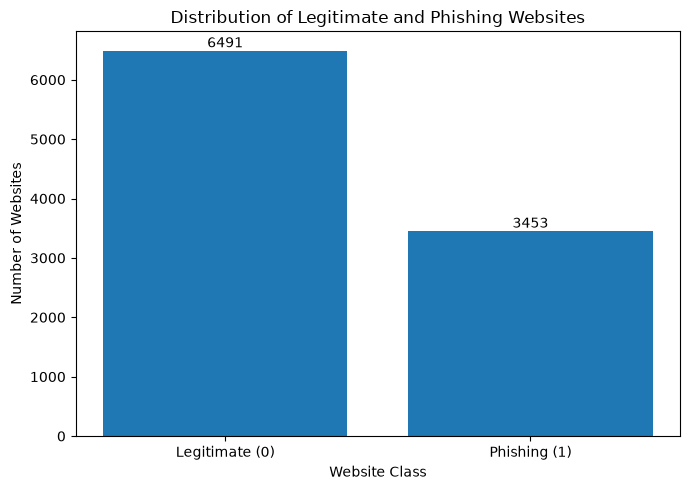

In [5]:
# ============================================
# Data VISUALIZATION
# Target Class DISTRIBUTION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df_cleaned = pd.read_csv('phishing_website_cleaned.csv')

# Count target classes
class_counts = (
    df_cleaned['phishing']
    .value_counts()
    .sort_index()
)

# Create labels
labels = ['Legitimate (0)', 'Phishing (1)']

values = [
    class_counts.get(0, 0),
    class_counts.get(1, 0)
]

# Plot
plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    values
)

# Add counts on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Legitimate and Phishing Websites')
plt.xlabel('Website Class')
plt.ylabel('Number of Websites')

plt.tight_layout()
plt.show()

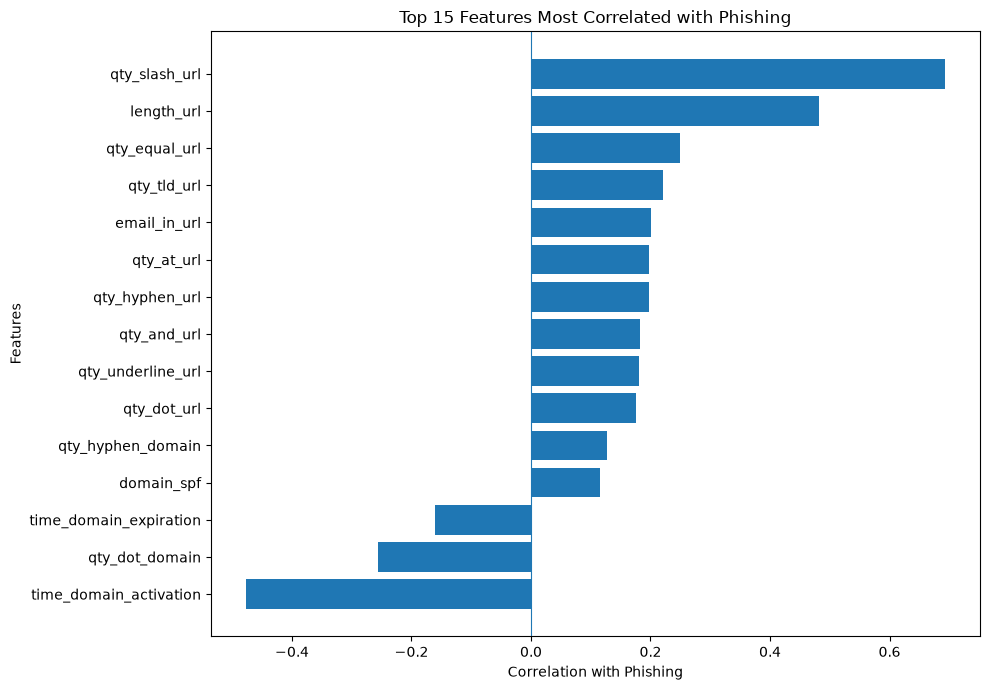

In [6]:
# ============================================
# VISUALIZATION
# TOP FEATURES CORRELATED WITH PHISHING
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load feature-selected dataset
df_selected = pd.read_csv(
    'phishing_website_feature_selected.csv'
)

# Calculate correlation with target
correlation = (
    df_selected
    .corr(numeric_only=True)['phishing']
    .drop('phishing')
)

# Get top 15 features by absolute correlation
top_features = (
    correlation
    .abs()
    .nlargest(15)
)

# Get original positive/negative correlation
top_correlation = correlation[
    top_features.index
].sort_values()

# Plot
plt.figure(figsize=(10, 7))

plt.barh(
    top_correlation.index,
    top_correlation.values
)

plt.axvline(
    x=0,
    linewidth=0.8
)

plt.title(
    'Top 15 Features Most Correlated with Phishing'
)

plt.xlabel('Correlation with Phishing')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

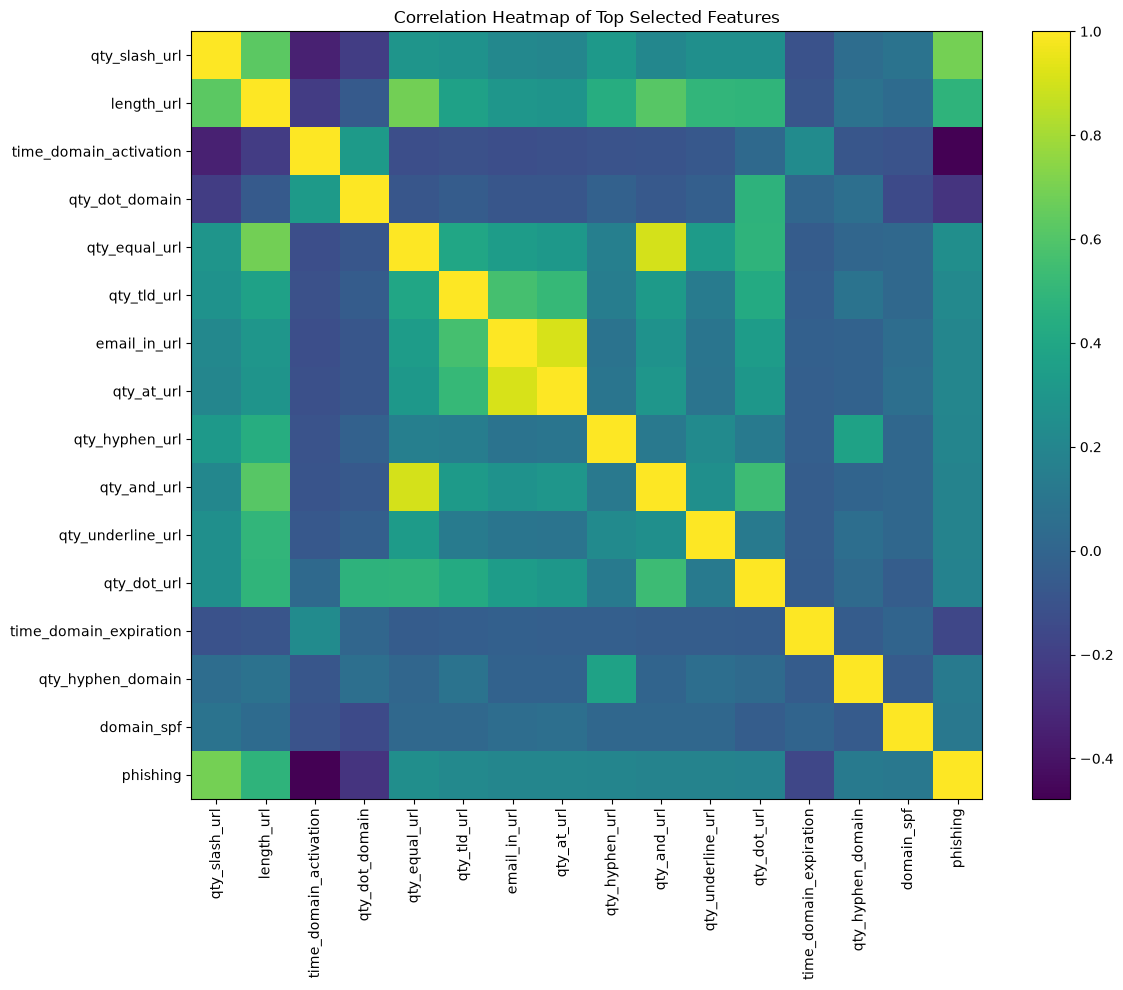

In [7]:
# ============================================
# VISUALIZATION
# CORRELATION HEATMAP
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load selected dataset
df_selected = pd.read_csv(
    'phishing_website_feature_selected.csv'
)

# Calculate correlation matrix
corr_matrix = df_selected.corr(
    numeric_only=True
)

# If too many features exist, use top 15
top_features = (
    corr_matrix['phishing']
    .drop('phishing')
    .abs()
    .nlargest(15)
    .index
    .tolist()
)

# Add target
features_for_heatmap = (
    top_features + ['phishing']
)

# Create smaller correlation matrix
heatmap_matrix = df_selected[
    features_for_heatmap
].corr()

# Plot
plt.figure(figsize=(12, 10))

image = plt.imshow(
    heatmap_matrix,
    aspect='auto'
)

plt.colorbar(image)

plt.xticks(
    range(len(heatmap_matrix.columns)),
    heatmap_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(heatmap_matrix.columns)),
    heatmap_matrix.columns
)

plt.title(
    'Correlation Heatmap of Top Selected Features'
)

plt.tight_layout()
plt.show()